Processed cleaned dataset saved successfully!
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


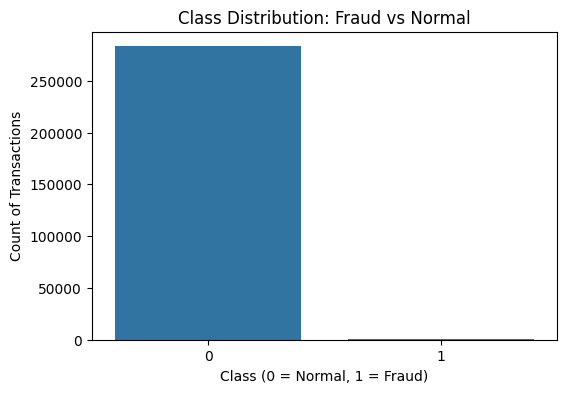

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

df = pd.read_csv("../data/raw/creditcard.csv")

# --------------------------------------------------
# Basic Understanding
# --------------------------------------------------

print("Shape of dataset:")
print(df.shape)

print("\nColumn Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# --------------------------------------------------
# Missing Value Check
# --------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# --------------------------------------------------
# Duplicate Check
# --------------------------------------------------

print("\nDuplicate Rows Before Removal:")
print(df.duplicated().sum())

# --------------------------------------------------
# Remove Duplicates
# --------------------------------------------------

initial_rows = df.shape[0]

df = df.drop_duplicates()

final_rows = df.shape[0]

removed_rows = initial_rows - final_rows

print("\nAfter Removing Duplicates:")
print(f"Initial Rows: {initial_rows}")
print(f"Final Rows: {final_rows}")
print(f"Duplicate Rows Removed: {removed_rows}")

# --------------------------------------------------
# Verify Duplicate Removal
# --------------------------------------------------

print("\nDuplicate Rows After Removal:")
print(df.duplicated().sum())

# --------------------------------------------------
# Save Processed Cleaned Dataset
# --------------------------------------------------

df.to_csv("../data/processed/creditcard_cleaned.csv", index=False)

print("\nProcessed cleaned dataset saved successfully!")

# --------------------------------------------------
# Class Distribution Analysis
# --------------------------------------------------

print("\nClass Distribution (Count):")
print(df['Class'].value_counts())

print("\nClass Distribution (Percentage):")
print(df['Class'].value_counts(normalize=True) * 100)

# --------------------------------------------------
# Countplot: Fraud vs Normal Transactions
# --------------------------------------------------

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)

plt.title("Class Distribution: Fraud vs Normal")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count of Transactions")

plt.show()

# --------------------------------------------------
# Transaction Amount Analysis
# --------------------------------------------------

print("\nTransaction Amount Summary:")
print(df['Amount'].describe())

print("\nTransaction Amount by Class:")
print(df.groupby('Class')['Amount'].describe())

# --------------------------------------------------
# Boxplot: Transaction Amount by Class
# --------------------------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

# --------------------------------------------------
# Time-Based Fraud Analysis
# --------------------------------------------------

print("\nTime Column Summary:")
print(df['Time'].describe())

print("\nTime Analysis by Class:")
print(df.groupby('Class')['Time'].describe())

# --------------------------------------------------
# Correlation Analysis
# --------------------------------------------------

print("\nCorrelation with Class:")
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
print(corr_with_class)

plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------------
# Histogram: Fraud Distribution by V14
# --------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='V14', hue='Class', kde=True)

plt.title("Fraud Distribution by V14")
plt.xlabel("V14")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------------
# Histogram: Fraud Distribution by V17
# --------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='V17', hue='Class', kde=True)

plt.title("Fraud Distribution by V17")
plt.xlabel("V17")
plt.ylabel("Frequency")

plt.show()

# --------------------------------------------------
# Executive KPI Summary
# --------------------------------------------------

total_transactions = len(df)
fraud_transactions = df['Class'].sum()
fraud_percentage = (fraud_transactions / total_transactions) * 100
avg_fraud_amount = df[df['Class'] == 1]['Amount'].mean()

print("\nExecutive KPI Summary")
print(f"Total Transactions: {total_transactions}")
print(f"Fraud Transactions: {fraud_transactions}")
print(f"Fraud Percentage: {round(fraud_percentage, 4)}%")
print(f"Average Fraud Amount: {round(avg_fraud_amount, 2)}")